# Mini Trabalho 3: Exploração dos Dados - Síntese de Correlações e Guia de Modelagem

Este notebook tem como objetivo consolidar a análise exploratória realizada anteriormente, gerando uma matriz de correlação global entre as variáveis numéricas do dataset. A partir dessa análise, busca-se identificar relações relevantes entre atributos,
além de orientar futuras etapas de pré-processamento e modelagem.

### Bibliotecas Usadas e Configuração Inicial

Importação das bibliotecas necessárias para análise e visualização dos dados.

In [1]:
#import sys
#!"{sys.executable}" -m pip install matplotlib seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

<Figure size 1000x600 with 0 Axes>

### Carregamento dos dados

Carregamento do dataset principal para análise exploratória.

In [2]:
df = pd.read_csv("../data/alzheimers_disease_data.csv")

# Visualizar as primeiras linhas
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


### Preparação dos dados

Verificação de integridade e preparação do dataset para análise de correlação.

In [6]:
# Informações gerais do dataset
df.info()

# Verificar valores nulos
df.isnull().sum()

# Verificar duplicados
df.duplicated().sum()

# Remover colunas que não contribuem para análise
df = df.drop(columns=["PatientID", "DoctorInCharge"], errors="ignore")
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        2149 non-null   int64  
 1   Gender                     2149 non-null   int64  
 2   Ethnicity                  2149 non-null   int64  
 3   EducationLevel             2149 non-null   int64  
 4   BMI                        2149 non-null   float64
 5   Smoking                    2149 non-null   int64  
 6   AlcoholConsumption         2149 non-null   float64
 7   PhysicalActivity           2149 non-null   float64
 8   DietQuality                2149 non-null   float64
 9   SleepQuality               2149 non-null   float64
 10  FamilyHistoryAlzheimers    2149 non-null   int64  
 11  CardiovascularDisease      2149 non-null   int64  
 12  Diabetes                   2149 non-null   int64  
 13  Depression                 2149 non-null   int64  
 14  Hea

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,...,6.518877,0,0,1.725883,0,0,0,1,0,0
1,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,...,7.118696,0,0,2.592424,0,0,0,0,1,0
2,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,...,5.895077,0,0,7.119548,0,1,0,1,0,0
3,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,...,8.965106,0,1,6.481226,0,0,0,0,0,0
4,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,...,6.045039,0,0,0.014691,0,0,1,1,0,0


- O dataset não apresenta valores nulos nem registros duplicados.
- As colunas de identificação, como PatientID e DoctorInCharge,
foram removidas por não contribuírem para a análise.
- Os dados encontram-se consistentes e prontos para a etapa de análise de correlação.

### Análise das correlações

Análise de correlação entre as variáveis, com foco na consolidação dos diferentes grupos analisados anteriormente.

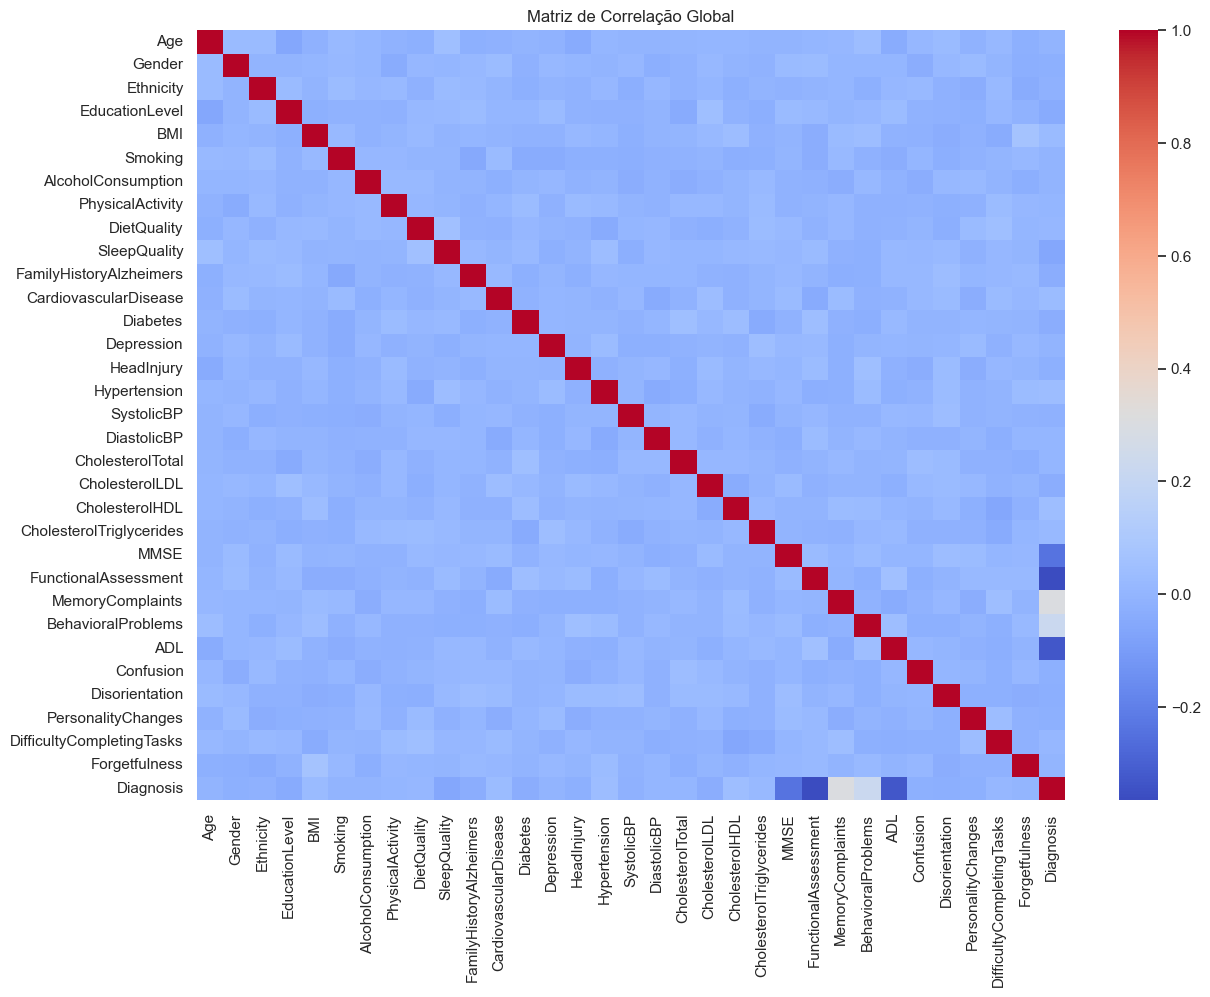

In [7]:
#Matriz de Correlação Global
corr = df.corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Matriz de Correlação Global")
plt.show()

In [15]:
#Definição dos grupos
clinico = [
    "Hypertension", "Diabetes", "CholesterolTotal", "CholesterolLDL",
    "CholesterolHDL", "CholesterolTriglycerides"
]

cognitivo = [
    "MMSE", "MemoryComplaints", "Confusion",
    "Disorientation", "Forgetfulness"
]

funcional = [
    "ADL", "FunctionalAssessment"
]

comportamental = [
    "BehavioralProblems", "PersonalityChanges",
    "DifficultyCompletingTasks"
]

demografico = [
    "Age", "Gender", "EducationLevel"
]

#Correlação do diagnóstico
corr_target = corr["Diagnosis"]

#Consolidação das correlações por grupo
corr_target.sort_values(ascending=False).to_frame(name="Correlação com Diagnosis")


,Correlação com Diagnosis
Diagnosis,1.000000
MemoryComplaints,0.306742
BehavioralProblems,0.224350
CholesterolHDL,0.042584
Hypertension,0.035080
CardiovascularDisease,0.031490
BMI,0.026343
CholesterolTriglycerides,0.022672
DifficultyCompletingTasks,0.009069
DietQuality,0.008506


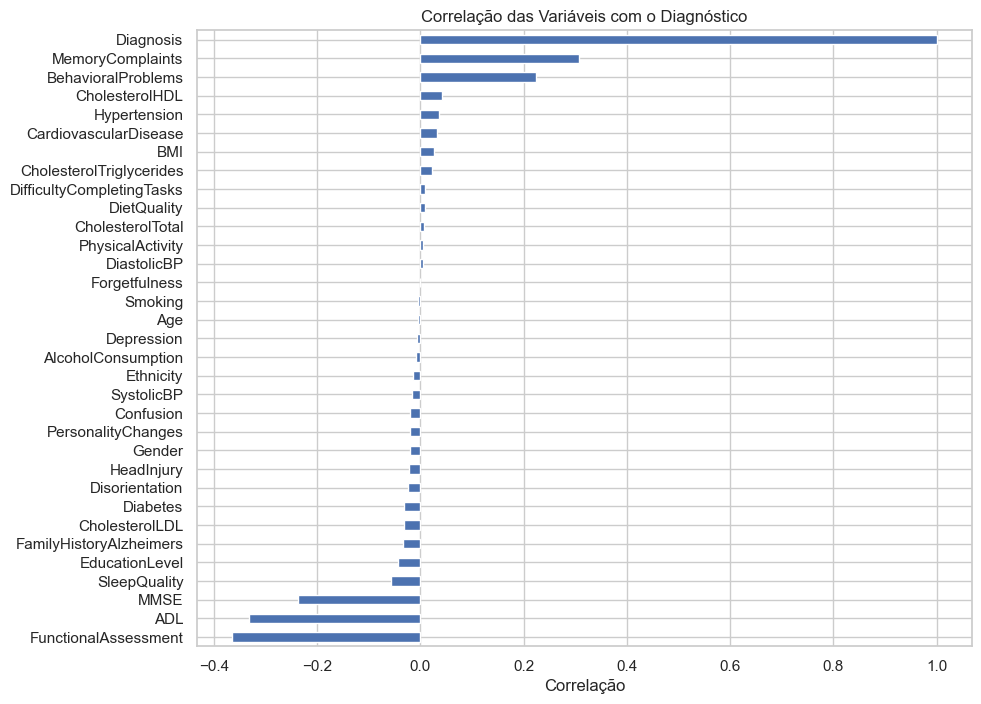

In [16]:
corr_target.sort_values().plot(kind="barh", figsize=(10,8))
plt.title("Correlação das Variáveis com o Diagnóstico")
plt.xlabel("Correlação")
plt.show()

### Análise dos resultados
A matriz de correlação global oferece uma visão geral das relações entre todas as variáveis do dataset, permitindo identificar padrões de associação de forma visual. De maneira geral, observa-se que a maioria das variáveis apresenta correlações fracas entre si, o que indica baixa dependência linear entre os atributos. Esse comportamento é positivo, pois reduz a presença de multicolinearidade e sugere que as variáveis carregam informações complementares para a modelagem.

Ao observar especificamente a coluna relacionada ao diagnóstico (Diagnosis), nota-se a presença de correlações mais intensas em algumas variáveis, destacando-se principalmente aquelas ligadas à capacidade funcional e ao estado cognitivo dos pacientes. Esses padrões visuais já indicam que esses grupos possuem maior relevância na identificação da doença.

A análise numérica das correlações confirma essa percepção. As variáveis funcionais, como FunctionalAssessment e ADL, apresentam as maiores correlações negativas com o diagnóstico, evidenciando que a redução da capacidade de realizar atividades diárias está fortemente associada à presença de Alzheimer. Em seguida, no grupo cognitivo, MemoryComplaints se destaca com correlação positiva relevante, enquanto o MMSE apresenta correlação negativa significativa, indicando que piores desempenhos cognitivos estão diretamente ligados ao diagnóstico.

As variáveis comportamentais, como BehavioralProblems, apresentam correlação moderada, sugerindo que alterações no comportamento contribuem para a identificação da condição, embora com menor impacto em comparação aos fatores funcionais e cognitivos. Por outro lado, variáveis clínicas e demográficas, como colesterol, pressão arterial, idade e gênero, apresentam correlações muito baixas, indicando que possuem pouca influência direta no diagnóstico quando analisadas isoladamente.

Em conjunto, os resultados mostram que o diagnóstico de Alzheimer, neste dataset, está muito mais associado a manifestações diretas da doença — como declínio cognitivo e perda de funcionalidade — do que a fatores clínicos ou demográficos gerais. Essa visão integrada reforça os achados das análises anteriores e fornece uma base consistente para a seleção de variáveis na etapa de modelagem preditiva.


### Conclusão

Os resultados obtidos na análise de correlação mostram-se consistentes com os achados apresentados nos notebooks anteriores.

As variáveis cognitivas e funcionais, previamente identificadas como relevantes, também se destacam nesta análise consolidada como os principais fatores associados ao diagnóstico, reforçando a importância do comprometimento cognitivo e da perda de capacidade funcional na identificação da doença.

As variáveis comportamentais mantêm uma influência moderada, enquanto fatores clínicos e demográficos apresentam baixa correlação, corroborando as análises específicas realizadas anteriormente.

Dessa forma, a análise global não apenas confirma os resultados obtidos de forma isolada, mas também os integra, fornecendo uma visão mais abrangente e coerente dos dados.